## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


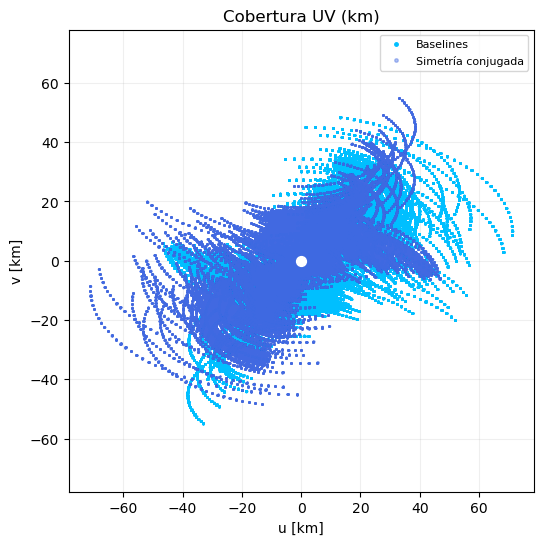

In [3]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/skalow.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T00:00:00",
    "utc_end": "2023-11-21T06:00:00",
    "step_min": 10,
    "n_freqs": 50,
    'bandwidth': 1e06, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 1,
    "max_offset_deg": 1, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ = visibilities_simulation(SKA_LOW_AA1)

plot_uv_coverage(uvw, unit='km')

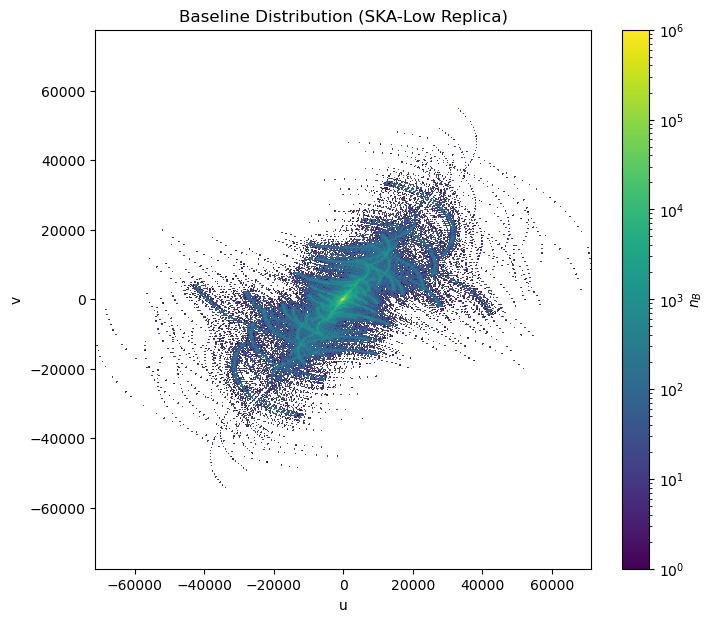

In [11]:
def plot_uv_density_paper_style(uvw, bins=512):
    # Extraemos u y v (asegúrate de que estén en las unidades deseadas, ej. baselines)
    u = uvw[..., 0].flatten()
    v = uvw[..., 1].flatten()
    
    # El paper asume simetría conjugada completa
    u_full = np.concatenate([u, -u])
    v_full = np.concatenate([v, -v])
    
    plt.figure(figsize=(8, 7))
    
    # Histograma 2D con escala logarítmica para n_B
    # El rango debe coincidir con la extensión de tus baselines (ej. -250 a 250)
    h = plt.hist2d(u_full, v_full, bins=bins, 
                   cmap='viridis', # O 'YlGnBu_r' para un look similar
                   norm=colors.LogNorm(vmin=1, vmax=1e6)) # Rango 10^0 a 10^6 como el paper
    
    plt.colorbar(label='$n_B$')
    plt.xlabel('u')
    plt.ylabel('v')
    plt.title('Baseline Distribution (SKA-Low Replica)')
    plt.axis('equal')
    plt.show()

plot_uv_density_paper_style(uvw, 512)

In [12]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
print("Primeros 5 registros del baseline 0: \n", V[0][:5])   

uvw shape:  (130816, 37, 3)
V shape:  (130816, 37, 50)
V baselines shape:  (37, 50)
Primeros 5 registros del baseline 0: 
 [[ 1.2771267 +1.1314442j   1.230939  +1.1815276j   1.1827887 +1.2297273j
   1.1327527 +1.2759662j   1.0809106 +1.3201708j   1.027345  +1.3622704j
   0.97214144+1.4021981j   0.9153879 +1.43989j     0.8571749 +1.4752862j
   0.7975952 +1.5083303j   0.7367438 +1.5389694j   0.6747177 +1.5671549j
   0.6116159 +1.5928416j   0.5475389 +1.6159887j   0.48258892+1.6365592j
   0.4168695 +1.6545205j   0.3504854 +1.6698438j   0.2835425 +1.6825047j
   0.21614753+1.692483j    0.14840792+1.6997627j   0.08043169+1.7043325j
   0.01232723+1.7061847j  -0.0557969 +1.7053167j  -0.12383205+1.7017297j
  -0.19166978+1.6954294j  -0.25920188+1.686426j   -0.32632074+1.6747338j
  -0.3929193 +1.6603713j  -0.4588914 +1.6433614j  -0.52413183+1.6237316j
  -0.5885366 +1.6015127j  -0.652003  +1.5767405j  -0.71442986+1.5494542j
  -0.7757176 +1.5196975j  -0.8357685 +1.4875178j  -0.89448696+1.4529665j
 

In [20]:
from modules.noise import narrowband_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=10,
    k_rfi=7,
    seed=42
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi

Canal RFI: 7
Frecuencia [MHz]: 182.5


In [21]:
def plot_visibility_waterfall_publication(
    V,
    frequencies,
    eps=1e-6,
    figsize=(10, 6),
    title_suffix=""
):
    """
    Publication-style waterfall plot (time vs frequency)
    matching standard radio astronomy figures.
    """

    frequencies = np.asarray(frequencies)

    # Average over baselines
    V_tf = np.mean(V, axis=0)  # (time, freq)

    # --- Amplitude ---
    amp = np.abs(V_tf)
    amp_log = np.log10(amp / np.median(amp) + eps)

    vmin = np.percentile(amp_log, 5)
    vmax = np.percentile(amp_log, 99.5)

    # --- Phase ---
    phase = np.angle(V_tf)

    extent = [
        frequencies.min() / 1e6,
        frequencies.max() / 1e6,
        0,
        amp_log.shape[0]
    ]

    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True)

    im0 = axs[0].imshow(
        amp_log,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        extent=extent
    )
    axs[0].set_ylabel("Time Integrations")
    axs[0].set_title(f"Amplitude (log scale) {title_suffix}")
    plt.colorbar(im0, ax=axs[0], label="log₁₀(|V| / median)")

    im1 = axs[1].imshow(
        phase,
        aspect="auto",
        origin="lower",
        cmap="twilight",
        vmin=-np.pi,
        vmax=np.pi,
        extent=extent
    )
    axs[1].set_xlabel("Frequency [MHz]")
    axs[1].set_ylabel("Time Integrations")
    axs[1].set_title(f"Phase {title_suffix}")
    plt.colorbar(im1, ax=axs[1], label="Phase [rad]")

    plt.tight_layout()
    plt.show()


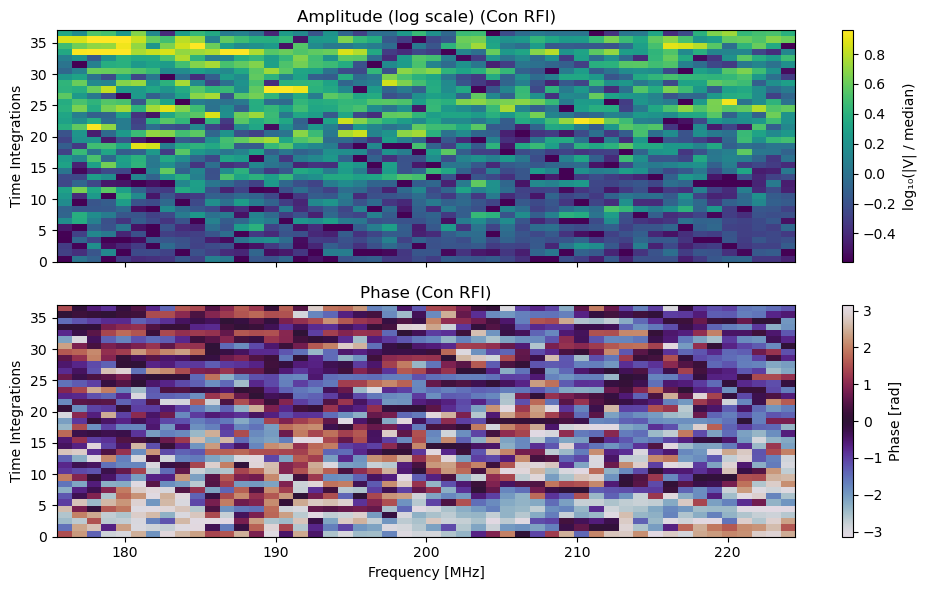

In [22]:
plot_visibility_waterfall_publication(
    V,
    frequencies,
    title_suffix="(Con RFI)"
)


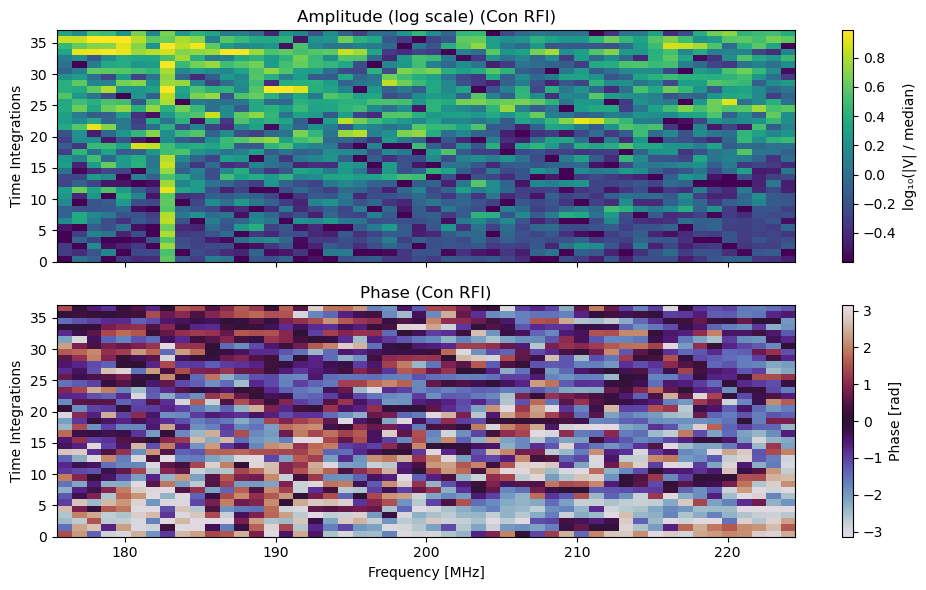

In [23]:
plot_visibility_waterfall_publication(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)
